# ParkCast SF — Exploratory Data Analysis
**Predict where to park — before you leave.**

---

This notebook profiles core data sources for ParkCast SF:

| # | Dataset | Source | Direct Link |
|---|---------|--------|-------------|
| 1 | Parking Meter Transactions | DataSF (SFMTA) | [API](https://data.sfgov.org/resource/imvp-dq3v.json) · [CSV](https://data.sfgov.org/api/views/imvp-dq3v/rows.csv?accessType=DOWNLOAD) · [Web](https://data.sfgov.org/Transportation/SFMTA-Parking-Meter-Detailed-Revenue-Transactions/imvp-dq3v) |
| 2 | Parking Meter Locations | DataSF (SFMTA) | [API](https://data.sfgov.org/resource/8vzz-qzz9.json) · [GeoJSON](https://data.sfgov.org/resource/8vzz-qzz9.geojson) · [Web](https://data.sfgov.org/Transportation/Parking-Meters/8vzz-qzz9) |
| 3 | Street Sweeping Schedule | DataSF (DPW) | [API](https://data.sfgov.org/resource/yhqp-riqs.json) · [CSV](https://data.sfgov.org/api/views/yhqp-riqs/rows.csv?accessType=DOWNLOAD) · [Web](https://data.sfgov.org/City-Infrastructure/Street-Sweeping-Schedule/yhqp-riqs) |
| 4 | Weather (Hourly) | Open-Meteo | [Forecast API](https://api.open-meteo.com/v1/forecast?latitude=37.7749&longitude=-122.4194&hourly=temperature_2m,precipitation,weathercode,windspeed_10m,cloudcover&timezone=America/Los_Angeles) · [Historical API](https://open-meteo.com/en/docs/historical-weather-api) |
| 5 | Street-Use Permits | DataSF (DPW) | [API](https://data.sfgov.org/resource/b6tj-gt35.json) · [Web](https://data.sfgov.org/City-Infrastructure/Street-Use-Permits/b6tj-gt35) |
| 6 | SFpark Historical Sensor Data | SFMTA | [Download Page](https://www.sfmta.com/getting-around/drive-park/demand-responsive-pricing/sfpark-evaluation) · [Sensor Guide (PDF)](https://www.sfmta.com/sites/default/files/reports-and-documents/2018/08/sfpark_dataguide_parkingsensordata.pdf) |


## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Dark theme for all plots
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d29',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'axes.edgecolor': '#333',
    'grid.color': '#2a2d3a',
    'font.family': 'sans-serif',
    'font.size': 11,
})

DATA_DIR = 'data'
print("Ready.")

Ready.


## 1. Download Data

Pull samples from each API. The Socrata (DataSF) endpoints support `$limit`, `$order`, `$where` filtering via URL params. Open-Meteo requires no API key.


In [ ]:
import os, urllib.request

os.makedirs(DATA_DIR, exist_ok=True)

datasets = {
    "meter_transactions.csv": (
        "https://data.sfgov.org/resource/imvp-dq3v.csv?$limit=50000&$order=session_start_dt%20DESC",
        "SFMTA Parking Meter Transactions (50k most recent)"
    ),
    "meter_locations.csv": (
        "https://data.sfgov.org/resource/8vzz-qzz9.csv?$limit=50000",
        "All Parking Meter Locations"
    ),
    "street_sweeping.csv": (
        "https://data.sfgov.org/resource/yhqp-riqs.csv?$limit=50000",
        "Street Sweeping Schedule"
    ),
    "street_use_permits.csv": (
        "https://data.sfgov.org/resource/b6tj-gt35.csv?$limit=10000&$order=data_as_of%20DESC",
        "Street-Use Permits (10k most recent)"
    ),
}

for filename, (url, desc) in datasets.items():
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {desc}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"Already have {filename}")
    print(f"  → {os.path.getsize(path) / 1e6:.1f} MB")

# Weather — Open-Meteo (last 90 days, hourly)
weather_path = os.path.join(DATA_DIR, "weather.csv")
if not os.path.exists(weather_path):
    print("Downloading Open-Meteo weather (last 90 days)...")
    weather_url = (
        "https://api.open-meteo.com/v1/forecast?"
        "latitude=37.7749&longitude=-122.4194"
        "&hourly=temperature_2m,relative_humidity_2m,precipitation,rain,weathercode,windspeed_10m,cloudcover"
        "&past_days=90&forecast_days=1&timezone=America/Los_Angeles"
    )
    urllib.request.urlretrieve(weather_url, os.path.join(DATA_DIR, "weather_raw.json"))
    with open(os.path.join(DATA_DIR, "weather_raw.json")) as f:
        wdata = json.load(f)
    hourly = wdata['hourly']
    pd.DataFrame(hourly).to_csv(weather_path, index=False)
    print(f"  → {os.path.getsize(weather_path) / 1e6:.1f} MB")
else:
    print(f"Already have weather.csv")
    print(f"  → {os.path.getsize(weather_path) / 1e6:.1f} MB")

print("\nAll datasets ready.")

Already have meter_transactions.csv
  → 6.7 MB
Already have meter_locations.csv
  → 14.2 MB
Already have street_sweeping.csv
  → 8.8 MB
Already have street_use_permits.csv
  → 5.2 MB
Already have weather.csv
  → 0.1 MB

All datasets ready.


## 2. Parking Meter Transactions

Every time someone pays a parking meter in SF, a row gets recorded. You get the meter ID (`post_id`), the block it's on, when the session started and ended, how much they paid, and whether it was a new session or extending time. This is our **core signal** — by counting active sessions per block per hour, we can estimate how full a block is. The full dataset is massive; the 50k sample here covers just ~2 days.

**Key fields:**
- `post_id` — unique meter ID (joins to locations table)
- `street_block` — block-level label (e.g. "MISSION ST 4700")
- `session_start_dt` / `session_end_dt` — parking session window
- `gross_paid_amt` — amount paid in dollars
- `payment_type` — PAY BY CELL, CREDIT CARD, CASH, or SMART CARD
- `meter_event_type` — NS (new session) or AT (add time to existing session)

**Why it matters for ParkCast:** By aggregating transaction start/end times per block, we can build an occupancy proxy — the number of meters with an active paid session at any given hour. This becomes the target variable for our prediction model.


In [ ]:
txn = pd.read_csv(f'{DATA_DIR}/meter_transactions.csv', low_memory=False)
txn['session_start_dt'] = pd.to_datetime(txn['session_start_dt'], errors='coerce')
txn['session_end_dt'] = pd.to_datetime(txn['session_end_dt'], errors='coerce')
txn['gross_paid_amt'] = pd.to_numeric(txn['gross_paid_amt'], errors='coerce')
txn['duration_min'] = (txn['session_end_dt'] - txn['session_start_dt']).dt.total_seconds() / 60

print(f"Shape: {txn.shape}")
print(f"Date range: {txn['session_start_dt'].min()} → {txn['session_start_dt'].max()}")
print(f"\nNull counts:")
print(txn.isnull().sum())
txn.head()

Shape: (50000, 9)
Date range: 2026-03-29 10:19:43 → 2026-03-30 22:07:13

Null counts:
transmission_datetime    0
post_id                  0
street_block             0
payment_type             0
session_start_dt         0
session_end_dt           0
meter_event_type         0
gross_paid_amt           0
duration_min             0
dtype: int64


,transmission_datetime,post_id,street_block,payment_type,session_start_dt,session_end_dt,meter_event_type,gross_paid_amt,duration_min
0,2558036082_9_03302026220713,916-00001,Pierce Street Garage,PAY BY CELL,2026-03-30 22:07:13,2026-03-31 22:07:13,NS,26.00,1440.000000
1,46196070_11_03302026215331,471-01002,HARRISON ST 100,CREDIT CARD,2026-03-30 21:53:31,2026-03-30 22:00:22,NS,0.25,6.850000
2,46196064_11_03302026214810,330-03004,BRANNAN ST 300,CASH,2026-03-30 21:48:10,2026-03-30 22:00:20,NS,0.25,12.166667
3,46196065_11_03302026214800,373-02010,CHANNEL ST 200,CASH,2026-03-30 21:48:00,2026-03-30 22:00:14,NS,0.25,12.233333
4,2558031336_9_03302026214614,860-04140,MISSION BAY BLVD NORTH 400,PAY BY CELL,2026-03-30 21:46:14,2026-03-30 22:00:00,NS,0.25,13.766667


In [ ]:
print("=== Key Stats ===")
print(f"Unique meters (post_id):  {txn['post_id'].nunique():,}")
print(f"Unique blocks:            {txn['street_block'].nunique():,}")
print(f"Median payment:           ${txn['gross_paid_amt'].median():.2f}")
print(f"Median session duration:  {txn['duration_min'].median():.0f} min")
print(f"\n=== Payment Types ===")
print(txn['payment_type'].value_counts())
print(f"\n=== Meter Event Types ===")
print(txn['meter_event_type'].value_counts())
print(f"\n=== Payment Amount Distribution ===")
print(txn['gross_paid_amt'].describe())
print(f"\n=== Session Duration Distribution ===")
print(txn['duration_min'].describe())

=== Key Stats ===
Unique meters (post_id):  10,491
Unique blocks:            1,567
Median payment:           $1.92
Median session duration:  50 min

=== Payment Types ===
payment_type
PAY BY CELL    19432
CREDIT CARD    19147
CASH           11374
SMART CARD        47
Name: count, dtype: int64

=== Meter Event Types ===
meter_event_type
NS    41693
AT     8307
Name: count, dtype: int64

=== Payment Amount Distribution ===
count    50000.000000
mean         3.590873
std          4.556233
min          0.040000
25%          0.750000
50%          1.920000
75%          4.580000
max         88.250000
Name: gross_paid_amt, dtype: float64

=== Session Duration Distribution ===
count    50000.000000
mean        80.136355
std        102.447401
min          0.250000
25%         20.000000
50%         50.000000
75%        111.000000
max       2222.883333
Name: duration_min, dtype: float64


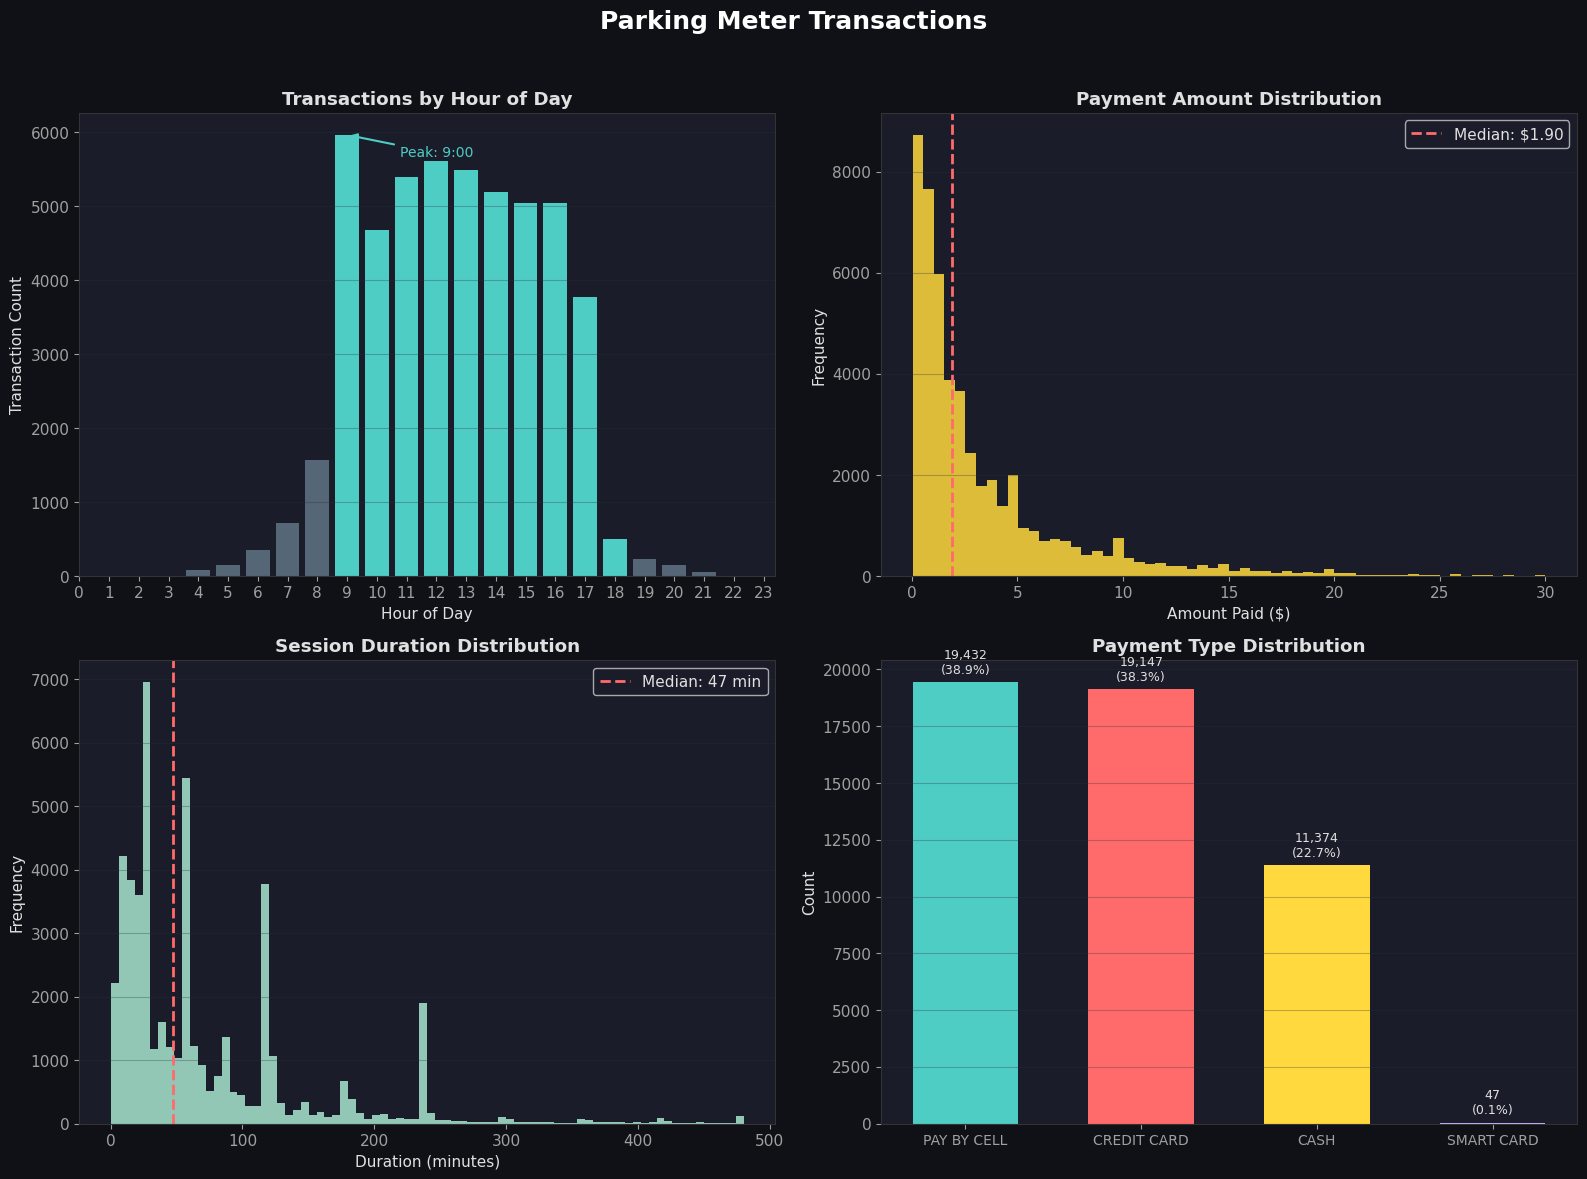

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Parking Meter Transactions', fontsize=18, fontweight='bold', color='white')

# Transactions by hour
ax = axes[0, 0]
txn_valid = txn.dropna(subset=['session_start_dt'])
hourly = txn_valid['session_start_dt'].dt.hour.value_counts().sort_index()
colors = ['#4ecdc4' if 9 <= h <= 18 else '#556677' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors, edgecolor='none', width=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Transaction Count')
ax.set_title('Transactions by Hour of Day', fontweight='bold')
ax.set_xticks(range(0, 24))
ax.grid(axis='y', alpha=0.3)
peak = hourly.idxmax()
ax.annotate(f'Peak: {peak}:00', xy=(peak, hourly.max()),
            xytext=(peak + 3, hourly.max() * 0.95),
            fontsize=10, color='#4ecdc4', ha='center',
            arrowprops=dict(arrowstyle='->', color='#4ecdc4', lw=1.5))

# Payment amount
ax = axes[0, 1]
valid_amt = txn['gross_paid_amt'].dropna()
valid_amt = valid_amt[(valid_amt > 0) & (valid_amt <= 30)]
ax.hist(valid_amt, bins=60, color='#ffd93d', edgecolor='none', alpha=0.85)
ax.axvline(valid_amt.median(), color='#ff6b6b', linestyle='--', lw=2, label=f'Median: ${valid_amt.median():.2f}')
ax.set_xlabel('Amount Paid ($)')
ax.set_ylabel('Frequency')
ax.set_title('Payment Amount Distribution', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Session duration
ax = axes[1, 0]
valid_dur = txn['duration_min'].dropna()
valid_dur = valid_dur[(valid_dur > 0) & (valid_dur <= 480)]
ax.hist(valid_dur, bins=80, color='#a8e6cf', edgecolor='none', alpha=0.85)
ax.axvline(valid_dur.median(), color='#ff6b6b', linestyle='--', lw=2, label=f'Median: {valid_dur.median():.0f} min')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Session Duration Distribution', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Payment types
ax = axes[1, 1]
pay = txn['payment_type'].value_counts()
colors_p = ['#4ecdc4', '#ff6b6b', '#ffd93d', '#c4b5fd'][:len(pay)]
ax.bar(range(len(pay)), pay.values, color=colors_p, edgecolor='none', width=0.6)
ax.set_xticks(range(len(pay)))
ax.set_xticklabels(pay.index, fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Payment Type Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(pay.values):
    ax.text(i, v + max(pay) * 0.02, f'{v:,}\n({v/len(txn)*100:.1f}%)', ha='center', fontsize=9, color='#e0e0e0')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
print("Top 15 busiest blocks:")
print(txn['street_block'].value_counts().head(15).to_string())

Top 15 busiest blocks:
street_block
Pierce Street Garage    542
WEST PORTAL AVE 300     327
PORTOLA DR 600          321
WEST PORTAL AVE 100     296
WEST PORTAL AVE 200     295
PORTOLA DR 700          241
WEST PORTAL AVE 0       240
IRVING ST 800           227
IRVING ST 2300          222
NORIEGA ST 2500         217
IRVING ST 2100          207
MISSION ST 4700         202
CLEMENT ST 400          196
OCEAN AVE 2600          196
24TH ST 4000            196


## 3. Parking Meter Locations

A lookup table of all 38,519 parking meters in the city — 30,933 currently active. Each has lat/lon coordinates, neighborhood, supervisor district, and cap color. We join this to transactions on `post_id` to get the geography.

**Key fields:**
- `post_id` — unique meter ID (join key to transactions)
- `latitude` / `longitude` — exact meter position
- `analysis_neighborhood` — SF neighborhood name
- `active_meter_flag` — M (metered, active), T (active, timed), U (unmetered/removed), P (planned), L (leased)
- `cap_color` — Grey (standard), Yellow (short-term), Green (long-term), Red (special), etc.
- `on_offstreet_type` — ON (street) or OFF (garage/lot)

**Data quality note:** Many legacy columns (`sensor_flag`, `parking_space_id`, `smart_meter_flag`, etc.) are 100% null — these are leftover schema from the SFpark pilot era and should be dropped. The core fields (location, active status, post_id) are clean.


In [ ]:
meters = pd.read_csv(f'{DATA_DIR}/meter_locations.csv', low_memory=False)
print(f"Shape: {meters.shape}")
print(f"\nActive meter flags:")
print(meters['active_meter_flag'].value_counts())
active_count = meters['active_meter_flag'].isin(['M', 'T']).sum()
print(f"\nActive meters (M + T): {active_count:,} / {len(meters):,}")
print(f"\nOn/Off street:")
print(meters['on_offstreet_type'].value_counts())
print(f"\nLat range: {meters['latitude'].min():.4f} → {meters['latitude'].max():.4f}")
print(f"Lon range: {meters['longitude'].min():.4f} → {meters['longitude'].max():.4f}")

# Null check — which columns are usable?
null_pct = (meters.isnull().sum() / len(meters) * 100).sort_values(ascending=False)
print(f"\nColumns with >50% null (drop these):")
print(null_pct[null_pct > 50].to_string())

Shape: (38519, 49)

Active meter flags:
active_meter_flag
M    26545
U     5062
T     4388
P     2458
L       66
Name: count, dtype: int64

Active meters (M + T): 30,933 / 38,519

On/Off street:
on_offstreet_type
ON     37584
OFF      935
Name: count, dtype: int64

Lat range: 37.7113 → 37.8085
Lon range: -122.4993 → -122.3823

Columns with >50% null (drop these):
legislation_ref          100.0
pco_beat                 100.0
parity_digit_position    100.0
smart_meter_flag         100.0
parking_space_id         100.0
orientation              100.0
spt_code                 100.0
nfc_key                  100.0
old_rate_area            100.0
osp_id                   100.0
legislation_dt           100.0
sensor_flag              100.0
work_order               100.0
comments                 100.0


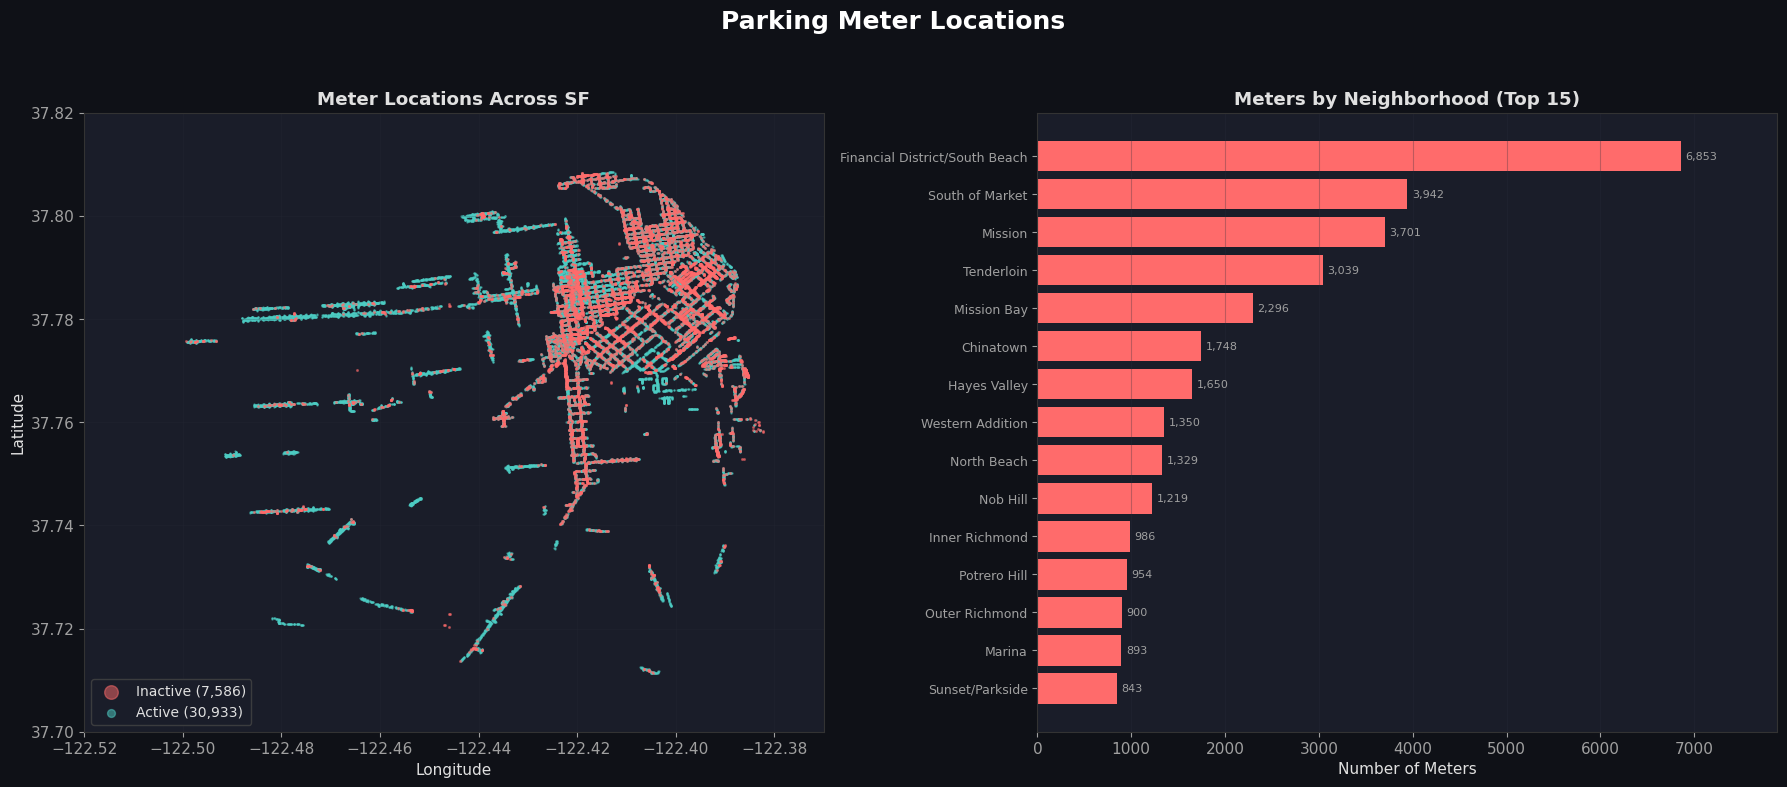

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Parking Meter Locations', fontsize=18, fontweight='bold', color='white')

# Map
ax = axes[0]
active = meters[meters['active_meter_flag'].isin(['M', 'T'])]
inactive = meters[~meters['active_meter_flag'].isin(['M', 'T'])]
ax.scatter(inactive['longitude'], inactive['latitude'], s=1.5, alpha=0.5, c='#ff6b6b', label=f'Inactive ({len(inactive):,})', zorder=2)
ax.scatter(active['longitude'], active['latitude'], s=0.5, alpha=0.5, c='#4ecdc4', label=f'Active ({len(active):,})', zorder=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Meter Locations Across SF', fontweight='bold')
ax.legend(fontsize=10, markerscale=8, loc='lower left', facecolor='#1a1d29', edgecolor='#444')
ax.set_xlim(-122.52, -122.37)
ax.set_ylim(37.70, 37.82)
ax.grid(alpha=0.2)

# Neighborhood bar
ax = axes[1]
hood = meters['analysis_neighborhood'].value_counts().head(15)
ax.barh(range(len(hood)), hood.values, color='#ff6b6b', edgecolor='none')
ax.set_yticks(range(len(hood)))
ax.set_yticklabels(hood.index, fontsize=9)
ax.set_xlabel('Number of Meters')
ax.set_title('Meters by Neighborhood (Top 15)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, hood.values[0] * 1.15)
for i, v in enumerate(hood.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=8, color='#a0a0a0')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Join Quality Check

Can we link every transaction to a meter location? This is critical — if the join breaks, we lose the ability to map transactions to geography.


In [ ]:
txn_ids = set(txn['post_id'].dropna().unique())
loc_ids = set(meters['post_id'].dropna().unique())
overlap = txn_ids & loc_ids

print("=== Join Quality (post_id) ===")
print(f"Meters in transactions:  {len(txn_ids):,}")
print(f"Meters in locations:     {len(loc_ids):,}")
print(f"Overlap:                 {len(overlap):,} ({len(overlap)/len(txn_ids)*100:.1f}% of txn meters)")
print(f"In txn but NOT in loc:   {len(txn_ids - loc_ids):,}  ← no orphaned transactions")
print(f"In loc but NOT in txn:   {len(loc_ids - txn_ids):,}  ← {len(loc_ids - txn_ids)/len(loc_ids)*100:.0f}% of meters had no txn in this sample")

print(f"\n=== Why {len(loc_ids - txn_ids):,} meters have no transactions ===")

# Break down the missing meters
missing_ids = loc_ids - txn_ids
missing_meters = meters[meters['post_id'].isin(missing_ids)]

print(f"  Inactive meters (U/P/L flags):  {missing_meters['active_meter_flag'].isin(['U','P','L']).sum():,}")
print(f"  Active but no txn in sample:    {missing_meters['active_meter_flag'].isin(['M','T']).sum():,}")
print(f"  Off-street (garage/lot):         {(missing_meters['on_offstreet_type'] == 'OFF').sum():,}")

print(f"\n⚠️  The join is clean (no orphans), but our 50k sample only covers ~2 days,")
print(f"   so most active meters simply didn't appear. Pull a larger time window")
print(f"   to get fuller coverage across all {len(loc_ids):,} meters.")

=== Join Quality (post_id) ===
Meters in transactions:  10,491
Meters in locations:     38,519
Overlap:                 10,491 (100.0% of txn meters)
In txn but NOT in loc:   0  ← no orphaned transactions
In loc but NOT in txn:   28,028  ← 73% of meters had no txn in this sample

=== Why 28,028 meters have no transactions ===
  Inactive meters (U/P/L flags):  5,620
  Active but no txn in sample:    22,408
  Off-street (garage/lot):         606

⚠️  The join is clean (no orphans), but our 50k sample only covers ~2 days,
   so most active meters simply didn't appear. Pull a larger time window
   to get fuller coverage across all 38,519 meters.


## 4. Street Sweeping Schedule

When sweepers come through a block, parking is banned — your car gets towed if it's there. This dataset tells you which block, which side of the street, which day, what hours, and which weeks of the month. ~7,000 blocks get swept each weekday, far fewer on weekends.

**Key fields:**
- `corridor` — street name
- `limits` — cross streets defining the block
- `weekday` — day of week (Mon, Tues, Wed, etc.)
- `fromhour` / `tohour` — sweeping window (e.g. 8–10 means 8am to 10am)
- `week1` through `week5` — binary flags for which weeks of the month sweeping occurs
- `cnnrightleft` / `blockside` — which side of the street
- `line` — GeoJSON LineString for the block geometry

**Why it matters for ParkCast:** This becomes a binary feature: "is parking banned on this block right now?" During sweep windows, available parking drops to zero on that side of the street, pushing demand to adjacent blocks.


In [ ]:
sweep = pd.read_csv(f'{DATA_DIR}/street_sweeping.csv', low_memory=False)
print(f"Shape: {sweep.shape}")
print(f"Unique corridors: {sweep['corridor'].nunique()}")
print(f"\nWeekday distribution:")
print(sweep['weekday'].value_counts())
print(f"\nHour ranges: {sweep['fromhour'].min()}–{sweep['fromhour'].max()} start, {sweep['tohour'].min()}–{sweep['tohour'].max()} end")
print(f"\nWeek flags (blocks swept per week of month):")
for w in ['week1','week2','week3','week4','week5']:
    print(f"  {w}: {sweep[w].sum():,}")
sweep.head()

Shape: (37878, 17)
Unique corridors: 1453

Weekday distribution:
weekday
Mon        7182
Tues       6891
Wed        6809
Thu        6798
Fri        6763
Sat        1340
Sun        1271
Holiday     824
Name: count, dtype: int64

Hour ranges: 0–13 start, 2–15 end

Week flags (blocks swept per week of month):
  week1: 30,664
  week2: 31,084
  week3: 30,562
  week4: 31,084
  week5: 26,491


,cnn,corridor,limits,cnnrightleft,blockside,fullname,weekday,fromhour,tohour,week1,week2,week3,week4,week5,holidays,blocksweepid,line
0,8753101,Market St,Larkin St - Polk St,L,SouthEast,Tuesday,Tues,5,6,1,1,1,1,1,0,1640782,"LINESTRING (-122.416291701103 37.777493843394,..."
1,8508000,Lower Great Hwy,Lincoln Way - Irving St,R,West,"Tue 1st, 3rd, 5th",Tues,13,15,1,0,1,0,1,0,1645051,"LINESTRING (-122.509833064656 37.763969286684,..."
2,397000,08th Ave,Judah St - Kirkham St,L,East,Wed 1st & 3rd,Wed,8,10,1,0,1,0,0,0,1636409,"LINESTRING (-122.465114853877 37.762221793442,..."
3,2184101,Alemany Blvd,Ralston St - Palmetto Ave,L,SouthEast,Thu 1st & 3rd,Thu,13,15,1,0,1,0,0,0,1628158,"LINESTRING (-122.467027507101 37.711494969725,..."
4,7985000,Laguna St,Francisco St - Bay St,R,East,Thu 1st & 3rd,Thu,9,11,1,0,1,0,0,0,1624216,"LINESTRING (-122.431497699329 37.802376296293,..."


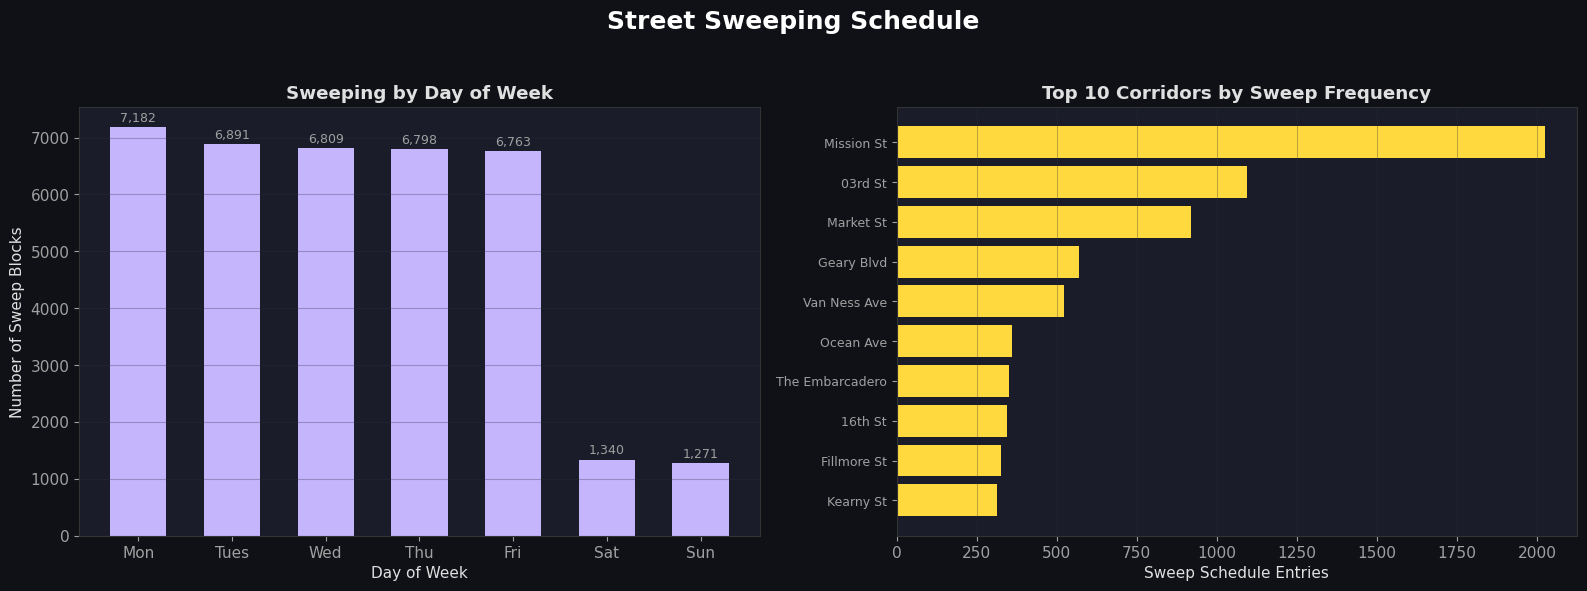

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Street Sweeping Schedule', fontsize=18, fontweight='bold', color='white')

# By day
ax = axes[0]
day_order = ['Mon', 'Tues', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sweep_days = sweep['weekday'].value_counts().reindex(day_order).fillna(0)
ax.bar(sweep_days.index, sweep_days.values, color='#c4b5fd', edgecolor='none', width=0.6)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Sweep Blocks')
ax.set_title('Sweeping by Day of Week', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(sweep_days.values):
    ax.text(i, v + 100, f'{int(v):,}', ha='center', fontsize=9, color='#a0a0a0')

# Top corridors
ax = axes[1]
top_corr = sweep['corridor'].value_counts().head(10)
ax.barh(range(len(top_corr)), top_corr.values, color='#ffd93d', edgecolor='none')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel('Sweep Schedule Entries')
ax.set_title('Top 10 Corridors by Sweep Frequency', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 5. Weather Data (Open-Meteo)

Hourly weather for SF — temperature, precipitation, wind, cloud cover, and WMO weather codes. Rain is rare in SF (only ~3-5% of hours), which means when it does rain, it likely changes parking behavior significantly — people drive instead of walk, park closer to destinations, and stay longer.

**Key fields:**
- `temperature_2m` — temperature at 2m height (°C)
- `precipitation` — total precipitation (mm)
- `rain` — rain specifically (mm)
- `weathercode` — WMO weather code (0 = clear, 1-3 = clouds, 51-67 = rain/drizzle, 71-77 = snow, 45/48 = fog)
- `windspeed_10m` — wind speed at 10m (km/h)
- `cloudcover` — cloud cover percentage
- `relative_humidity_2m` — relative humidity (%)

**API details (no key needed, free for non-commercial use):**
- **Forecast**: `https://api.open-meteo.com/v1/forecast?latitude=37.7749&longitude=-122.4194&hourly=...`
- **Historical** (back to 1940): `https://archive-api.open-meteo.com/v1/archive?latitude=37.7749&longitude=-122.4194&start_date=YYYY-MM-DD&end_date=YYYY-MM-DD&hourly=...`

**Why it matters for ParkCast:** Weather is a demand shifter. Rainy days change where and how long people park. We can use precipitation and temperature as features in the prediction model, and since Open-Meteo provides forecasts too, we can feed predicted weather into our 30-60 min parking forecasts.


In [ ]:
weather = pd.read_csv(f'{DATA_DIR}/weather.csv')
weather['time'] = pd.to_datetime(weather['time'])
print(f"Shape: {weather.shape}")
print(f"Date range: {weather['time'].min()} → {weather['time'].max()}")
print(f"\nPrecipitation > 0: {(weather['precipitation'] > 0).sum()} / {len(weather)} hours ({(weather['precipitation'] > 0).mean()*100:.1f}%)")
print(f"\nWeather code distribution (WMO codes):")
print(weather['weathercode'].value_counts().head(10))
print(f"\nSummary stats:")
weather.describe()

Shape: (2184, 8)
Date range: 2025-12-31 00:00:00 → 2026-03-31 23:00:00

Precipitation > 0: 75 / 2184 hours (3.4%)

Weather code distribution (WMO codes):
weathercode
0.0     717
3.0     423
2.0     130
1.0     129
51.0     35
53.0     12
61.0     12
45.0     10
63.0      9
55.0      7
Name: count, dtype: int64

Summary stats:


,time,temperature_2m,relative_humidity_2m,precipitation,rain,weathercode,windspeed_10m,cloudcover
count,2184,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,2026-02-14 11:30:00,14.111321,71.096361,0.056402,0.056402,4.186658,8.645418,43.465633
min,2025-12-31 00:00:00,3.100000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-01-22 17:45:00,10.600000,60.000000,0.000000,0.000000,0.000000,5.000000,1.000000
50%,2026-02-14 11:30:00,13.200000,75.000000,0.000000,0.000000,1.000000,7.600000,24.500000
75%,2026-03-09 05:15:00,16.800000,84.000000,0.000000,0.000000,3.000000,11.200000,98.000000
max,2026-03-31 23:00:00,31.700000,100.000000,7.200000,7.200000,63.000000,34.400000,100.000000
std,NaN,4.950418,16.530754,0.412702,0.412702,12.317044,5.244587,43.151142


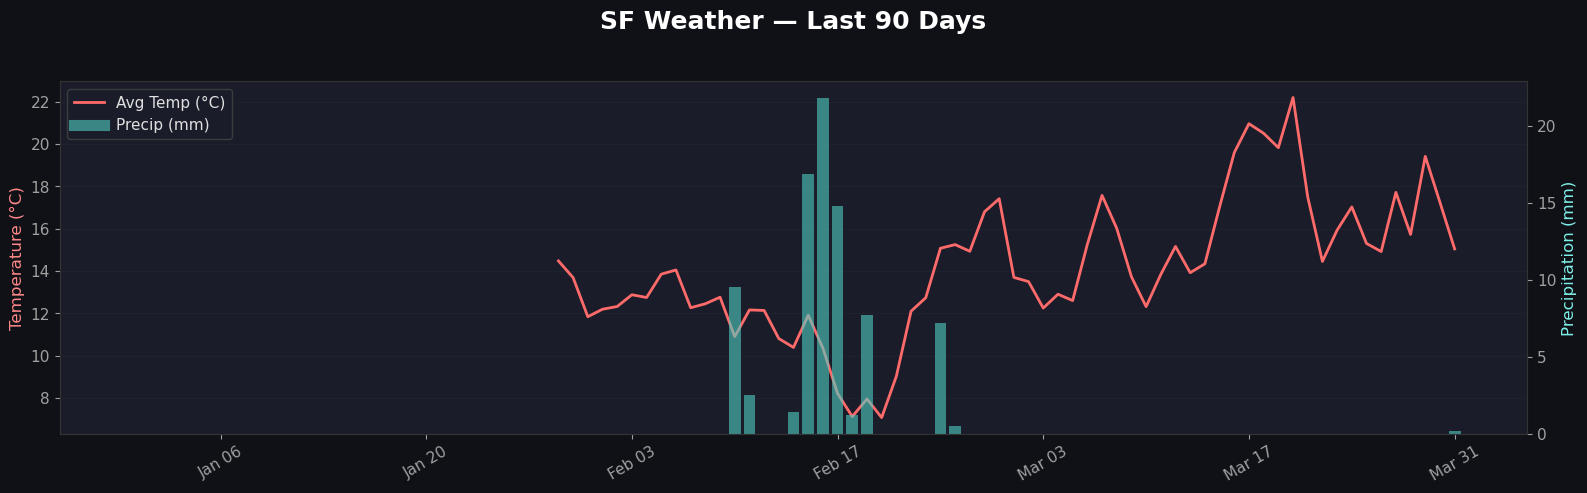

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('SF Weather — Last 90 Days', fontsize=18, fontweight='bold', color='white')

daily = weather.set_index('time').resample('D').agg({'temperature_2m': 'mean', 'precipitation': 'sum'})
ax2 = ax.twinx()
ax2.bar(daily.index, daily['precipitation'], color='#4ecdc4', alpha=0.6, width=0.8)
ax.plot(daily.index, daily['temperature_2m'], color='#ff6b6b', linewidth=2)
ax.set_ylabel('Temperature (°C)', fontsize=12, color='#ff8888')
ax2.set_ylabel('Precipitation (mm)', fontsize=12, color='#7eeee6')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(axis='y', alpha=0.3)
ax.plot([], [], color='#ff6b6b', lw=2, label='Avg Temp (°C)')
ax.plot([], [], color='#4ecdc4', lw=8, alpha=0.6, label='Precip (mm)')
ax.legend(loc='upper left', fontsize=11, facecolor='#1a1d29', edgecolor='#444')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Street-Use Permits (Events Proxy)

Permits for street closures, banners, excavation, and events. The `permit_purpose` field has event names like "Golden State Warriors Civic Celebration" or "Laver Cup SF." Most rows are banners (63%), so we'd want to filter for event-related types (TempOccup, ExcStreet, NightNoise) to build a meaningful events feature.

**Key fields:**
- `permit_type` — Banners, Excavation, TempOccup, NightNoise, etc.
- `permit_purpose` — free-text description (contains event names)
- `streetname` — affected street
- `latitude` / `longitude` — location
- `analysis_neighborhood` — SF neighborhood
- `status` — CLOSED, APPROVED, ACTIVE, EXPIRED, etc.
- `permit_start_date` / `permit_end_date` — when the permit is active (if available)

**Why it matters for ParkCast:** Events like Giants games, concerts, and street fairs cause unpredictable demand surges. Street closures remove parking supply entirely. By geocoding and time-matching permits to our block grid, we can create an "event proximity" feature that flags when a major event is happening nearby.

**Note:** For a more complete events picture, also consider the [SFpark Exogenous Events CSV](https://www.sfmta.com/getting-around/drive-park/demand-responsive-pricing/sfpark-evaluation) (historical) and the Oracle Park / Chase Center game schedules (which can be scraped from team websites).


In [ ]:
permits = pd.read_csv(f'{DATA_DIR}/street_use_permits.csv', low_memory=False)
print(f"Shape: {permits.shape}")
print(f"\nPermit types:")
print(permits['permit_type'].value_counts())
print(f"\nTop neighborhoods:")
print(permits['analysis_neighborhood'].value_counts().head(10))
print(f"\nSample event-related permit purposes:")
for p in permits['permit_purpose'].dropna().sample(10, random_state=42):
    print(f"  • {p[:120]}")

Shape: (10000, 31)

Permit types:
permit_type
Banners        6267
Excavation     2168
TempOccup       900
NightNoise      122
StrtImprov       80
Emergency        79
ExcStreet        66
Parklet          50
MinorEnc         50
Shelters         32
StorCont         32
AddlStSpac       30
Sidewalk         26
TableChair       22
SideSewer        17
Wireless         12
conformity        9
OverwideDr        8
Vault             8
Referral          7
TankRemove        5
SpecSide          4
StreetSpace       2
Display           2
MajorEnc          1
SurfaceFac        1
Name: count, dtype: int64

Top neighborhoods:
analysis_neighborhood
Financial District/South Beach    878
Mission                           827
Marina                            766
Sunset/Parkside                   735
South of Market                   625
Tenderloin                        555
Western Addition                  540
Hayes Valley                      440
Chinatown                         373
Bayview Hunters Point   

## 7. SFpark Historical Sensor Data (2011–2013)

The motherlode for training. During the SFpark pilot, SFMTA embedded 12,000+ sensors in parking spaces across SF that measured actual occupancy — whether a car was physically in the space or not. This produced a 1.38 GB CSV of hourly block-level occupancy from April 2011 to July 2013.

This is **actual measured occupancy**, not a proxy derived from payments. The pilot also collected matched exogenous data:
- Events (Giants games, concerts, parades)
- Weather
- Street closures
- Fuel prices
- Employment data

**The catch:** The sensors were removed after the pilot ended, so there's no live sensor data anymore. But these patterns (how occupancy varies by hour, day, weather, events) are still highly relevant for training a prediction model.

**Download page:** [SFMTA SFpark Evaluation](https://www.sfmta.com/getting-around/drive-park/demand-responsive-pricing/sfpark-evaluation)

**Key files:**
- `SFpark_ParkingSensorData_HourlyOccupancy_20112013.csv` (1.38 GB) — hourly occupancy by block
- `SFpark Exogenous Data Events.csv` — event calendar
- `SFpark Exogenous Data Weather.csv` — historical weather matched to pilot period
- [Sensor Data Guide (PDF)](https://www.sfmta.com/sites/default/files/reports-and-documents/2018/08/sfpark_dataguide_parkingsensordata.pdf) — data dictionary

> **Note:** These files are too large to download in this notebook. Download them separately and place in the `data/` folder if you want to explore them here.


## Summary & Next Steps

### Data Quality
| Dataset | Rows | Nulls | Join Key | Quality |
|---------|------|-------|----------|---------|
| Meter Transactions | 50k sample (full dataset much larger) | 0 nulls | `post_id` | ✅ Clean |
| Meter Locations | 38,519 (30,933 active) | Many legacy columns 100% null — drop them | `post_id` | ✅ Usable |
| Street Sweeping | 37,878 | Clean | `corridor` / geo join | ✅ Clean |
| Weather | 2,184 hourly | Clean | Temporal join | ✅ Clean |
| Street-Use Permits | 10,000 | Clean | Geo + temporal join | ⚠️ Mostly banners, filter for events |
| SFpark Sensor Data | ~1.38 GB | TBD | Block ID | ✅ Gold standard (but 2011–2013 only) |

### How the Datasets Connect

```
Meter Transactions ──(post_id)──► Meter Locations ──(lat/lon)──► Block Grid
       │                                │
       │ (temporal join)                 │ (spatial join)
       ▼                                ▼
    Weather                      Street Sweeping
  (hour-level)                  (block + day + hour)
       │                                │
       └────────────► Feature Matrix ◄───┘
                          │
                    Street-Use Permits
                   (geo + temporal join)
```

### Feature Engineering Ideas
1. **Occupancy proxy** — aggregate transactions per block per hour to estimate occupancy
2. **Temporal features** — hour, day of week, month, is_holiday, is_event_day
3. **Sweep windows** — binary flag for "parking banned on this block right now"
4. **Weather** — precipitation, temperature, cloud cover as demand shifters
5. **Rate features** — current meter rate (higher rates → more turnover)
6. **Event proximity** — distance/time to nearest major event from permits data
7. **Lag features** — occupancy at t-1, t-2, same hour yesterday, same hour last week

### Modeling Approach
- Gradient boosting (XGBoost/LightGBM) on block-level hourly features
- Target: estimated occupancy rate per block per hour
- Train on historical transaction patterns, validate on held-out time window
- Use SFpark sensor data (2011–2013) to validate that transaction-based occupancy proxy correlates with true sensor occupancy
